<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Semana10/Stroke_Predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [127]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
fedesoriano_stroke_prediction_dataset_path = kagglehub.dataset_download('fedesoriano/stroke-prediction-dataset')

print('Data source import complete.')


Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.
Data source import complete.


# Imports

In [128]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Data

In [129]:
df = pd.read_csv('/kaggle/input/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv')

In [130]:
df.head(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# Data Preprocessing

In [131]:
df.shape

(5110, 12)

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [133]:
df.drop('id', axis = 1, inplace = True)

In [134]:
df.head(1)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1


In [135]:
df.isna().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201
smoking_status,0


In [136]:
df.fillna(df['bmi'].mean(), inplace = True)

In [137]:
df.isna().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [139]:
df.head(1)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1


In [140]:
df.nunique()

,0
gender,3
age,104
hypertension,2
heart_disease,2
ever_married,2
work_type,5
Residence_type,2
avg_glucose_level,3979
bmi,419
smoking_status,4


In [141]:
for i in df['age']:
  d = int(i)
  if (d/i)!=1:
    print(i)

1.32
0.64
0.88
1.8
0.32
1.08
1.8
1.8
1.16
1.4
1.72
0.88
1.4
0.24
0.32
1.64
1.56
1.72
0.72
1.88
1.24
0.8
1.08
1.88
1.24
0.4
1.24
0.08
1.48
1.72
0.64
1.48
1.4
1.56
0.56
0.24
0.56
0.64
0.48
1.32
1.24
1.72
1.08
1.16
1.8
0.88
1.64
1.64
0.88
0.88
0.32
0.8
1.24
1.56
0.8
1.24
0.64
0.24
1.64
1.16
1.32
0.56
0.08
1.48
1.08
1.88
0.24
1.48
0.56
1.88
1.32
1.24
1.88
1.64
0.16
0.8
1.32
1.08
1.48
1.88
1.8
1.8
1.64
0.32
1.88
1.64
1.56
0.56
1.8
0.16
1.88
1.64
0.72
0.16
0.48
0.24
1.48
1.72
0.72
1.8
0.4
1.32
0.48
1.16
1.32
1.08
1.8
1.08
0.32
0.72
1.32
1.24
1.72
0.72
1.08


# Visualization

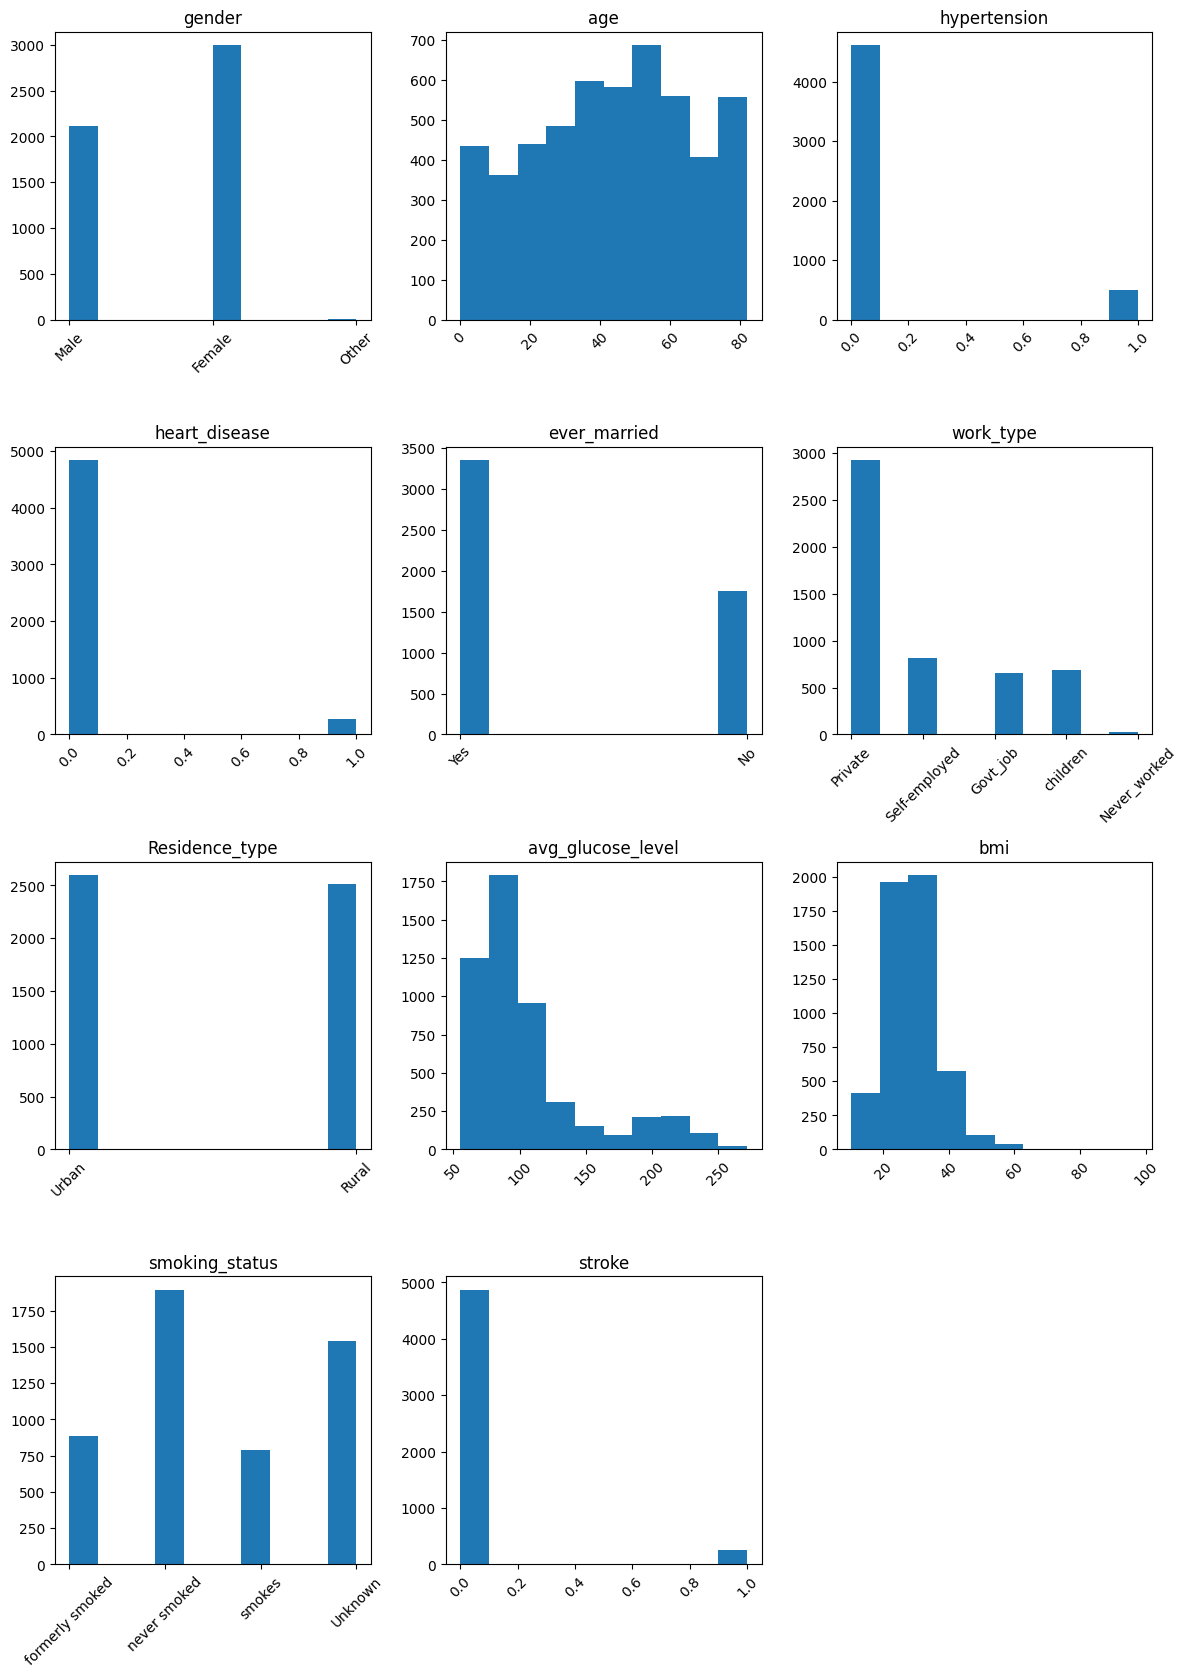

In [142]:
columns_list = list(df.columns)
plt.figure(figsize = (12,20))
for i in range(len(columns_list)):
    plt.subplot(5, 3, i + 1)
    plt.title(columns_list[i])
    plt.xticks(rotation = 45)
    plt.hist(df[columns_list[i]])

plt.tight_layout()

## Age

<Axes: xlabel='age'>

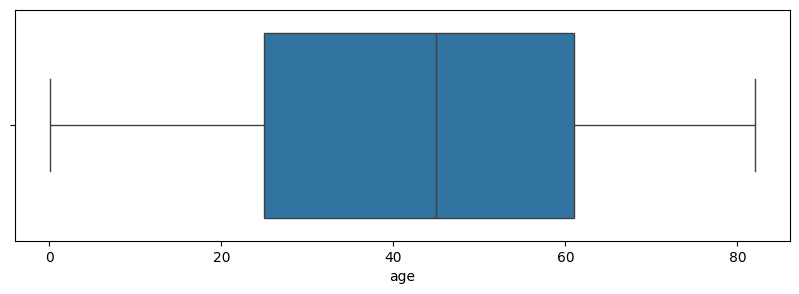

In [143]:
plt.figure(figsize = (10, 3))
sns.boxplot(x = 'age', data = df)

## Average Glucose Level

<Axes: xlabel='avg_glucose_level'>

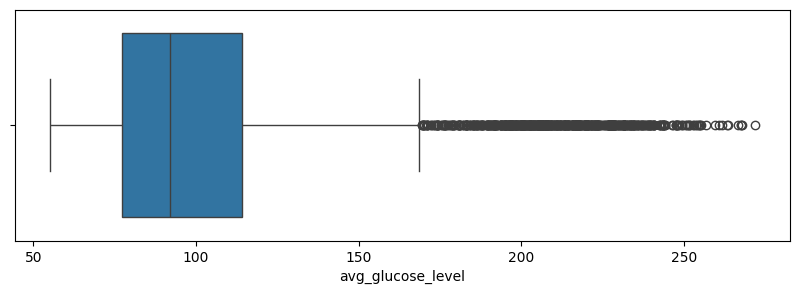

In [144]:
plt.figure(figsize = (10, 3))
sns.boxplot(x = 'avg_glucose_level', data = df)

## AVC Percent

([<matplotlib.patches.Wedge at 0x79fa91ce0320>,
 [Text(-1.0871361482645023, 0.16773489540528563, 'No Stroke'),
  Text(1.2847973307229401, -0.19823173047523968, 'Stroke')],
 [Text(-0.5929833535988194, 0.0914917611301558, '95.127%'),
  Text(0.790644511214117, -0.12198875721553208, '4.873%')])

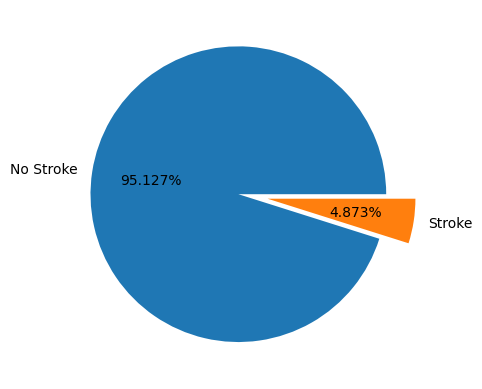

In [145]:
qtd_stroke = df['stroke'].value_counts()
plt.pie(qtd_stroke, labels = ['No Stroke','Stroke'], autopct='%.3f%%', explode = [0,0.2])

## Married

([<matplotlib.patches.Wedge at 0x79fa92429790>,
 [Text(-0.5182756139174329, 0.9702527444014307, 'Already Married'),
  Text(0.5324102528882477, -0.9967142632768292, 'Never Married')],
 [Text(-0.28269578940950885, 0.5292287696735076, '65.616%'),
  Text(0.29683049497309383, -0.5556902529773472, '34.384%')])

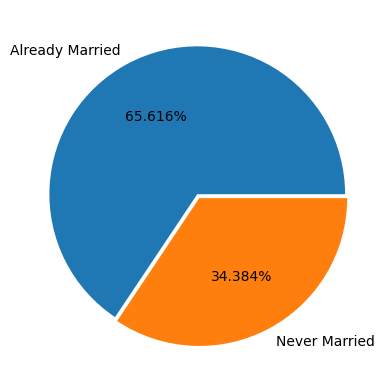

In [146]:
qtd_casado = df['ever_married'].value_counts()
plt.pie(qtd_casado, labels = ['Already Married', 'Never Married'], autopct = '%.3f%%', explode = [0,0.03])

## IDADE

/tmp/ipykernel_27964/450620810.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


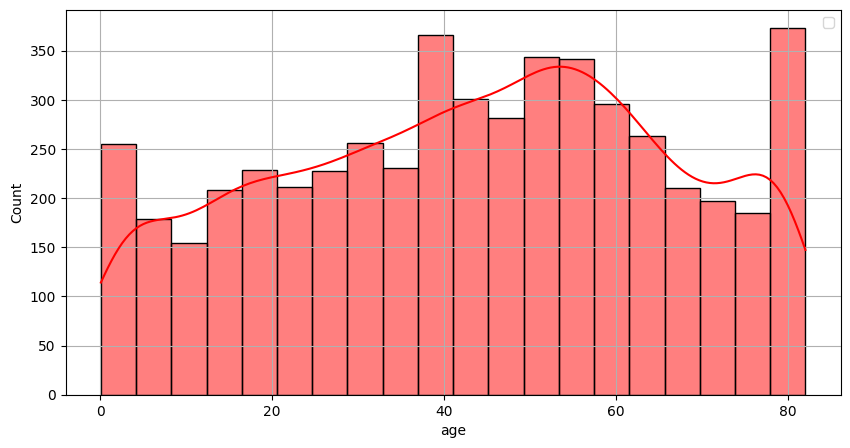

In [147]:
plt.figure(figsize=(10,5))
sns.histplot(df['age'], color = 'red', kde = True)
plt.legend()
plt.grid()

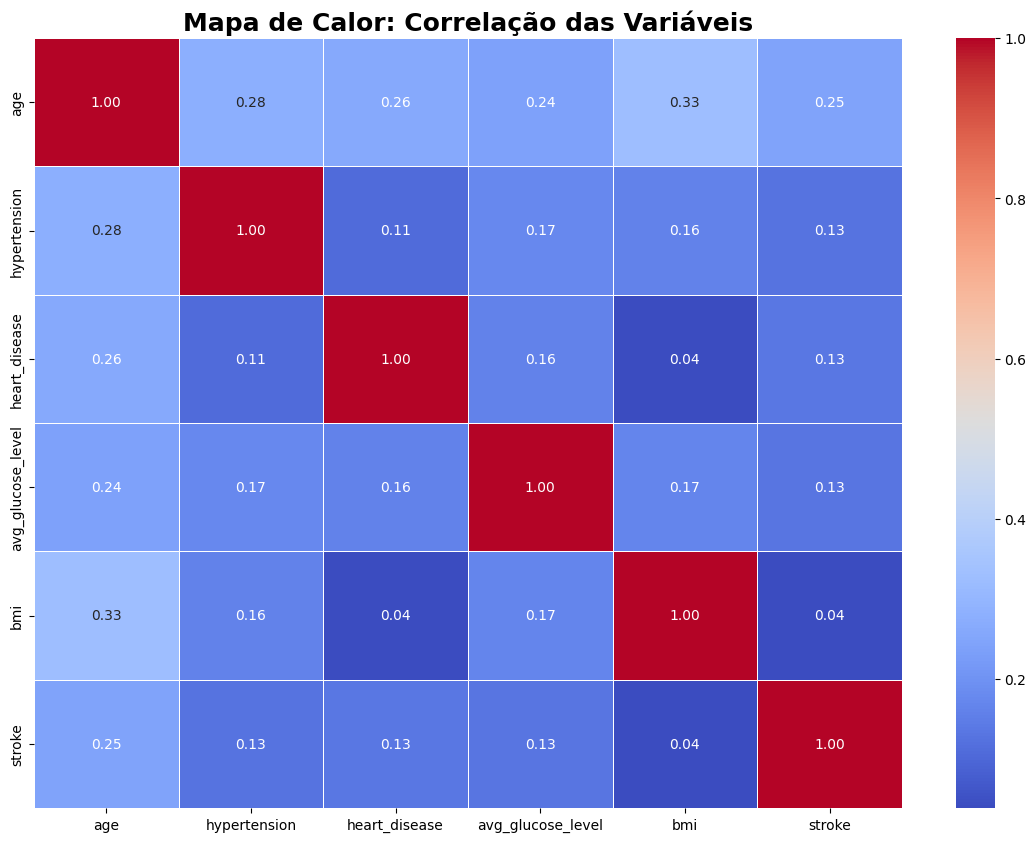

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------------------------------------------------------
# HEATMAP DE CORRELAÇÃO (Corrigido para ignorar texto)
# ------------------------------------------------------------------
plt.figure(figsize=(14, 10))

# Passo 1: Filtra o DataFrame para pegar APENAS colunas com números (int, float) ou booleanos (True/False)
df_numerico = df.select_dtypes(include=['number', 'bool'])

# Passo 2: Calcula a correlação apenas nesse DataFrame numérico
sns.heatmap(df_numerico.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Mapa de Calor: Correlação das Variáveis', fontsize=18, fontweight='bold')
plt.show()

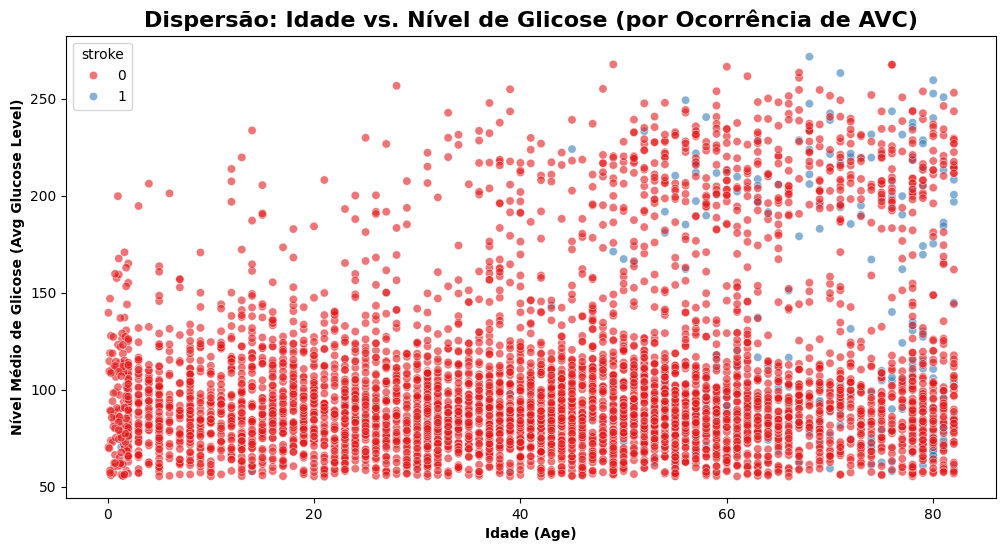

In [149]:

plt.figure(figsize=(12, 6))

# x e y são as variáveis contínuas
# hue='stroke' pinta os pontos de cores diferentes se a pessoa teve AVC ou não
# alpha=0.6 deixa os pontos levemente transparentes para ver onde há sobreposição
sns.scatterplot(data=df, x='age', y='avg_glucose_level', hue='stroke', palette='Set1', alpha=0.6)

plt.title('Dispersão: Idade vs. Nível de Glicose (por Ocorrência de AVC)', fontsize=16, fontweight='bold')
plt.xlabel('Idade (Age)', fontweight='bold')
plt.ylabel('Nível Médio de Glicose (Avg Glucose Level)', fontweight='bold')

plt.show()

# Convert Categorical Columns to Numeric

In [150]:
col_categ = df.select_dtypes(include = ['object']).columns.tolist()

In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [152]:
print(col_categ)

['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


In [153]:
df = pd.get_dummies(df, columns=col_categ, drop_first=True)

In [154]:
df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.600000,1,True,False,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,28.893237,1,False,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.500000,1,True,False,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.400000,1,False,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.000000,1,False,False,True,False,False,True,False,False,False,True,False


# Split Train and Test

In [155]:
X = df.drop('stroke', axis = 1)
y = df['stroke']

In [156]:
print(X)

       age  hypertension  heart_disease  avg_glucose_level        bmi  \
0     67.0             0              1             228.69  36.600000   
1     61.0             0              0             202.21  28.893237   
2     80.0             0              1             105.92  32.500000   
3     49.0             0              0             171.23  34.400000   
4     79.0             1              0             174.12  24.000000   
...    ...           ...            ...                ...        ...   
5105  80.0             1              0              83.75  28.893237   
5106  81.0             0              0             125.20  40.000000   
5107  35.0             0              0              82.99  30.600000   
5108  51.0             0              0             166.29  25.600000   
5109  44.0             0              0              85.28  26.200000   

      gender_Male  gender_Other  ever_married_Yes  work_type_Never_worked  \
0            True         False              T

In [157]:
print(y)

0       1
1       1
2       1
3       1
4       1
       ..
5105    0
5106    0
5107    0
5108    0
5109    0
Name: stroke, Length: 5110, dtype: int64


In [158]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size = 0.20, random_state = 42,stratify=y)

In [159]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Ajustar e transformar no treino
xtrain[['age', 'avg_glucose_level', 'bmi']] = scaler.fit_transform(xtrain[['age', 'avg_glucose_level', 'bmi']])

# Apenas transformar no teste (nunca fazer "fit" no teste para evitar vazamento de dados)
xtest[['age', 'avg_glucose_level', 'bmi']] = scaler.transform(xtest[['age', 'avg_glucose_level', 'bmi']])

# Data Balancing

In [160]:
from imblearn.over_sampling import SMOTE

# Removemos o drop_first daqui!
smt = SMOTE(random_state=42)

xtrain_res, ytrain_res = smt.fit_resample(xtrain, ytrain)

# Comparing models

In [161]:
# 6. Preparando os dois Modelos
rf = RandomForestClassifier(random_state=42)
lr = LogisticRegression(max_iter=2000, random_state=42)

# Predicts

In [162]:
# ==========================================================
# TESTANDO O MODELO 1: RANDOM FOREST
# ==========================================================
print("\n" + "="*50)
print("MODELO 1: RANDOM FOREST")
print("="*50)

# Sem balanceamento
rf.fit(xtrain, ytrain)
y_pred_rf = rf.predict(xtest)
print("\n[Random Forest] SEM Balanceamento:")
print(classification_report(ytest, y_pred_rf))

# Com balanceamento
rf.fit(xtrain_res, ytrain_res)
y_pred_rf_res = rf.predict(xtest)
print("\n[Random Forest] COM Balanceamento (SMOTE):")
print(classification_report(ytest, y_pred_rf_res))


MODELO 1: RANDOM FOREST

[Random Forest] SEM Balanceamento:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.25      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.60      0.51      0.51      1022
weighted avg       0.92      0.95      0.93      1022


[Random Forest] COM Balanceamento (SMOTE):
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       972
           1       0.14      0.26      0.19        50

    accuracy                           0.89      1022
   macro avg       0.55      0.59      0.56      1022
weighted avg       0.92      0.89      0.90      1022



In [163]:
# ==========================================================
# TESTANDO O MODELO 2: REGRESSÃO LOGÍSTICA
# ==========================================================
print("\n" + "="*50)
print("MODELO 2: REGRESSÃO LOGÍSTICA")
print("="*50)
# Sem balanceamento
lr.fit(xtrain, ytrain)
y_pred_lr = lr.predict(xtest)
print("\n[Random Forest] SEM Balanceamento:")
print(classification_report(ytest, y_pred_lr))

# Com balanceamento
lr.fit(xtrain_res, ytrain_res)
y_pred_lr_res = lr.predict(xtest)
print("\n[Random Forest] COM Balanceamento (SMOTE):")
print(classification_report(ytest, y_pred_lr_res))


MODELO 2: REGRESSÃO LOGÍSTICA

[Random Forest] SEM Balanceamento:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022


[Random Forest] COM Balanceamento (SMOTE):
              precision    recall  f1-score   support

           0       0.98      0.76      0.86       972
           1       0.14      0.74      0.23        50

    accuracy                           0.76      1022
   macro avg       0.56      0.75      0.55      1022
weighted avg       0.94      0.76      0.83      1022



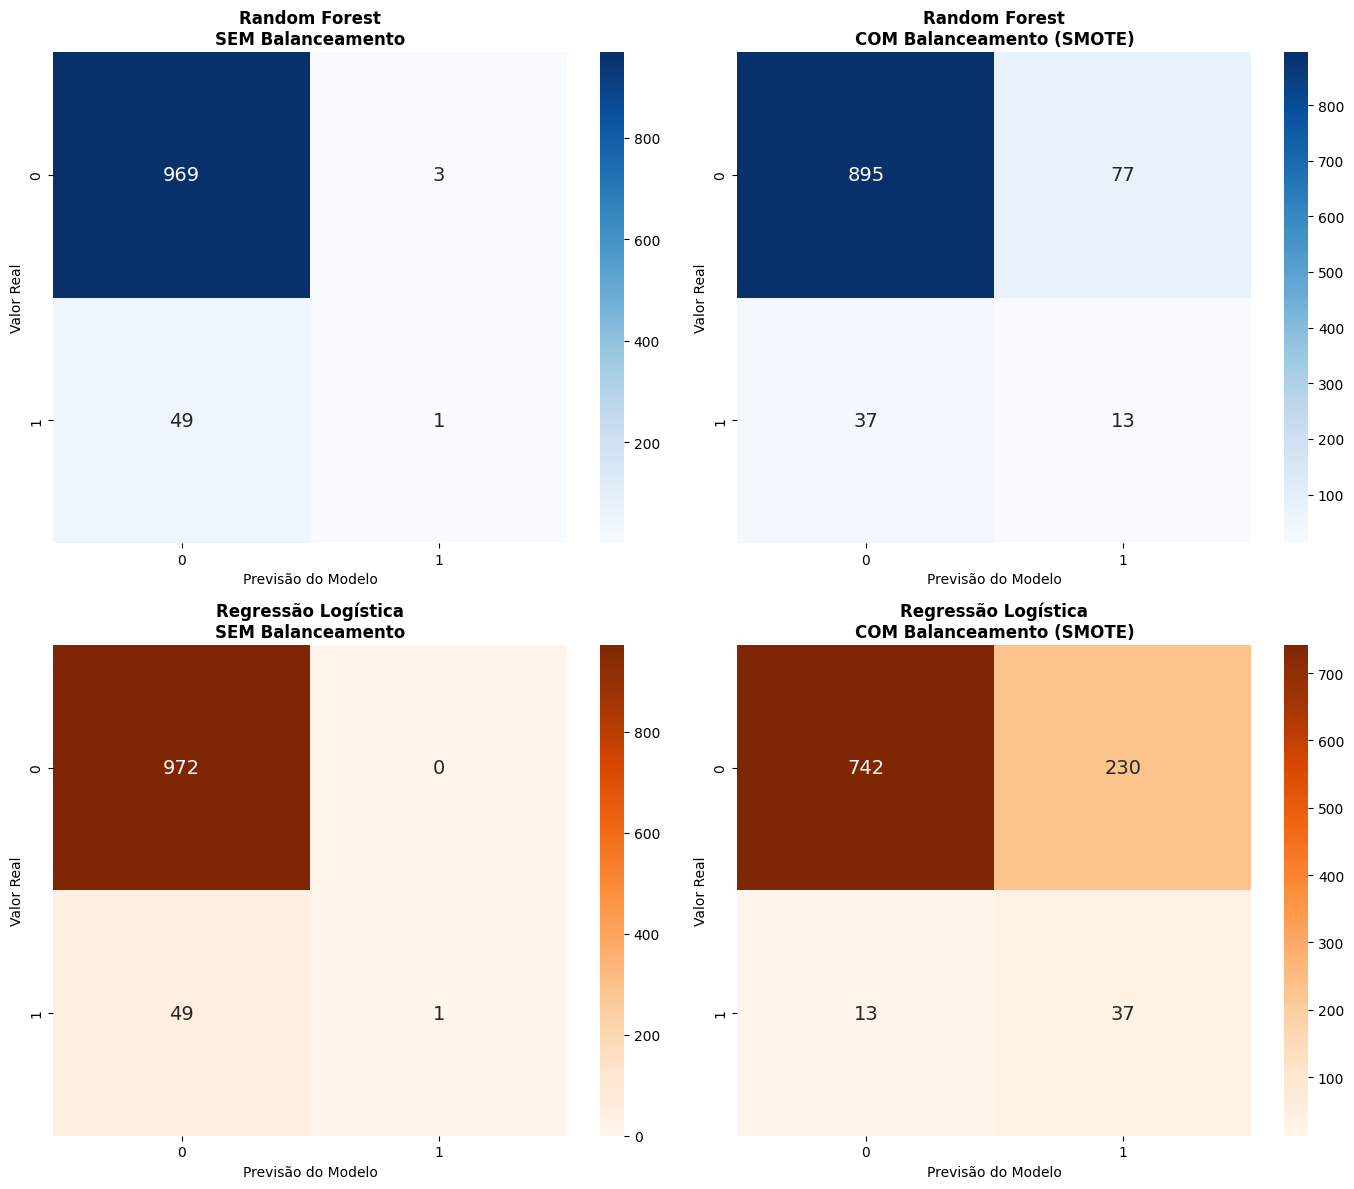

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calcular as matrizes de confusão usando os y_preds gerados no código anterior
cm_rf = confusion_matrix(ytest, y_pred_rf)
cm_rf_res = confusion_matrix(ytest, y_pred_rf_res)
cm_lr = confusion_matrix(ytest, y_pred_lr)
cm_lr_res = confusion_matrix(ytest, y_pred_lr_res)

# Criar a figura com subplots (2 linhas, 2 colunas)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# ==========================================================
# 1. Random Forest - SEM Balanceamento
# ==========================================================
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            annot_kws={"size": 14})
axes[0, 0].set_title('Random Forest\nSEM Balanceamento', fontweight='bold')
axes[0, 0].set_xlabel('Previsão do Modelo')
axes[0, 0].set_ylabel('Valor Real')

# ==========================================================
# 2. Random Forest - COM Balanceamento (SMOTE)
# ==========================================================
sns.heatmap(cm_rf_res, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
            annot_kws={"size": 14})
axes[0, 1].set_title('Random Forest\nCOM Balanceamento (SMOTE)', fontweight='bold')
axes[0, 1].set_xlabel('Previsão do Modelo')
axes[0, 1].set_ylabel('Valor Real')

# ==========================================================
# 3. Regressão Logística - SEM Balanceamento
# ==========================================================
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges', ax=axes[1, 0],
            annot_kws={"size": 14})
axes[1, 0].set_title('Regressão Logística\nSEM Balanceamento', fontweight='bold')
axes[1, 0].set_xlabel('Previsão do Modelo')
axes[1, 0].set_ylabel('Valor Real')

# ==========================================================
# 4. Regressão Logística - COM Balanceamento (SMOTE)
# ==========================================================
sns.heatmap(cm_lr_res, annot=True, fmt='d', cmap='Oranges', ax=axes[1, 1],
            annot_kws={"size": 14})
axes[1, 1].set_title('Regressão Logística\nCOM Balanceamento (SMOTE)', fontweight='bold')
axes[1, 1].set_xlabel('Previsão do Modelo')
axes[1, 1].set_ylabel('Valor Real')

# Ajustar o espaçamento entre os gráficos
plt.tight_layout()
plt.show()